# Text Classification on Social Media Commentary

Assignment devoloped by António Romão (up202108704), Guilherme Gonçalves (up202107768) and Pedro Leitão (up202107852) for the Natural Language Processing course at FEUP.

## Table of Contents
1. [Introduction](#1-introduction)
    - 1.1. [Context and Problem Statement](#11-context-and-problem-statement)
    - 1.2. [Assignment Objectives](#12-assignment-objectives)
2. [Data Provenance and Characteristics](#2-data-provenance-and-characteristics)
    - 2.1. [Origin and Collections Methods](#21-origin-and-collection-methods)
    - 2.2. [Annotation Methodology](#22-annotation-methodology)
    - 2.3. [Label Definitions](#23-label-definitions)
    - 2.4. [Initial Processing and Structure](#24-initial-processing-and-structure)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
    - 3.1. [Dataset Overview and Splits](#31-dataset-overview-and-splits)
    - 3.2. [Class Distribution and Balance](#32-class-distribution-and-balance)
    - 3.3. [Text Length Analysis](#33-text-length-analysis)
        - 3.3.1. [Overall Length Distribution](#331-overall-length-distribution)
        - 3.3.2. [Length Distribution by Class](#332-length-distribution-by-class)
    - 3.4. [Lexical Analysis and Word Distribution](#34-lexical-analysis-and-word-distribution)
        - 3.4.1. [Most Frequent Words (N-grams)](#341-most-frequent-words-n-grams)
        - 3.4.2. [TF-IDF Analysis](#342-tf-idf-analysis)
    - 3.5. [Special Tokens, Artifacts and Language Analysis](#35-special-tokens-artifacts-and-language-analysis)
4. [Data Pre-processing](#4-data-pre-processing)
    - 4.1. [Review of Inherited Processing (Baseline)](#41-review-of-inherited-processing-baseline)
    - 4.2. [Text Normalization and Cleaning](#42-text-normalization-and-cleaning)
        - 4.2.1. [Contraction Expansion](#421-contraction-expansion)
        - 4.2.2. [Selective Ponctuation and Special Character Removal](#422-selective-punctuation-and-special-character-removal)
    - 4.3. [Tokenization Strategy](#43-tokenization-strategy)
    - 4.4. [Stop Word and Domain-Specific Filler Removal](#44-stop-word-and-domain-specific-filler-removal)
    - 4.5. [Lemmatization vs. Stemming](#45-lemmatization-vs-stemming)
5. [Feature Extraction and Representation](#5-feature-extraction-and-representation)
    - 5.1. [Sparse Feature Representations (BoW / TF-IDF)](#51-sparse-feature-representations-bow--tf-idf)
    - 5.2. [Dense Feature Representations (Word Embeddings)](#52-dense-feature-representations-word-embeddings)
    - 5.3. [Integration of Engineered Features](#53-integration-of-engineered-features)
6. [Model Training and Selection](#6-model-training-and-selection)
7. [Model Evaluation](#7-model-evaluation)
8. [Error Analysis](#8-error-analysis)
9. [Related Work Comparison](#9-related-work-comparison)
10. [Conclusion](#10-conclusion)

## 1. Introduction

[[go back to top]](#table-of-contents)

This report presents the development and evaluation of Natural Language Processing (NLP) classifiers designed for a specialized text classification task. The introduction is divided into two main parts: first, it establishes the context and outlines the core problem by exploring the nuances of the provided social media commentary dataset; second, it details the specific academic objectives, scope, and technical constraints required for this assignment.

### 1.1. Context and Problem Statement

[[go back to section]](#1-introduction)

The landscape of online discourse is complex, and traditional sentiment analysis, often limited to simple 'positive', 'negative', or 'neutral' labels, is frequently insufficient for capturing the true nature of social media commentary. To better understand how users interact, debate, and communicate online, it is necessary to analyze the rhetorical purpose and communicative intent behind the text. 

The dataset provided for this assignment addresses this need by categorizing social media comments into five distinct, nuanced labels: Argumentative, Informational, Opinion, Expressive, and Neutral. These comments were specifically gathered using the search queries 'politics' or 'US Politics'. To ensure a diverse representation of online behavior, the data was sourced from multiple platforms with varying community norms, specifically YouTube, Hacker News, MetaFilter, Reddit, and BlueSky. The collection spans a timeframe from 2024 up to mid-February 2026.

**Problem Statement**: The core problem to be addressed in this assignment is the development of an effective Natural Language Processing (NLP) pipeline for text classification. The objective is to build robust machine learning classifiers capable of automatically categorizing these political social media comments into one of the five target labels. Successfully solving this problem involves navigating the inherent noise and variability of social media text through careful application of data pre-processing, feature extraction (including both sparse and dense representations), and traditional machine learning algorithms.

### 1.2. Assignment Objectives

[[go back to section]](#1-introduction)

The primary aim of this assignment is to build effective Natural Language Processing (NLP) classifiers for a specific text classification task. To achieve this, the project involves a comprehensive exploration of the standard NLP pipeline, including data pre-processing, feature extraction, and a comparative analysis of sparse versus dense feature representations, such as word embeddings. Prior to model development, a critical objective is to conduct an exploratory data analysis (EDA) to thoroughly understand the dataset, which includes documenting class sizes and word distributions (e.g., TF-IDF) supported by proper visualizations.

A core constraint of this project is the strict focus on "traditional" machine learning algorithms. The models explored will include classifiers such as Naive Bayes, Logistic Regression, Decision Trees, Random Forest, Support Vector Machines (SVM), Multi-Layer Perceptrons (MLP), or XGBoost. The implementation of any deep learning architectures based on Convolutional Neural Networks (CNNs), Recurrent Neural Networks (RNNs), or Transformers is explicitly prohibited for this assignment.

Finally, a rigorous evaluation methodology is required. This involves establishing a simple baseline model to benchmark future developments and reporting classifier performance using appropriate metrics such as Precision, Recall, F1, and macro-F1 scores. We will also undertake a detailed error analysis on the best-performing models to understand the reasons behind misclassifications. Furthermore, the project aims to frame our work by comparing our classifier results with any existing related work on the same problem, placing our achievements in the context of prior published research.

## 2. Data Provenance and Characteristics

[[go back to top]](#table-of-contents)

Before developing our text classifiers, the assignment requires us to establish a clear understanding of our data's provenance and inherent characteristics. To achieve this, we will examine the ADS509 Dataset, which serves as the foundation for this project. This dataset was specifically designed to capture the nuanced nature of social media commentary, moving beyond traditional 'positive', 'negative', or 'neutral' sentiment labels. The following subsections detail the sources, annotation methodology, label definitions, and initial processing steps used to construct this dataset, providing the necessary context for our subsequent exploratory data analysis and feature engineering.

### 2.1. Origin and Collection Methods

[[go back to section]](#2-data-provenance-and-characteristics)

To effectively classify the communicative intent behind online discourse, the data for this assignment was sourced from five distinct social media platforms: YouTube, Hacker News, MetaFilter, Reddit, and BlueSky. By utilizing multiple platforms, the dataset captures a wider variety of community norms and conversational styles. 

The collection focused specifically on political discussions, utilizing the targeted search queries 'politics' or 'US Politics'. The overall timeframe for the collected data ranges from 2024 to mid-February of 2026. However, the exact chronological span varies depending on the specific platform's traffic volume and API rate limits. For example, due to its heavy traffic, the Reddit collection hit daily rate limits and is consequently restricted to posts from just the first two weeks of February 2026. In contrast, data pulled from MetaFilter extends as far back as 2024.

Furthermore, specific structural filtering criteria were applied during the collection process to ensure data quality and balance:
* Posts containing fewer than 10 comments were entirely excluded from the dataset.
* A maximum threshold of 300 comments was extracted from any single post to prevent highly active or viral threads from disproportionately dominating the data distribution.

### 2.2. Annotation Methodology

[[go back to section]](#2-data-provenance-and-characteristics)


The annotation process for this dataset employed a hybrid approach, combining initial human validation with large-scale automated labeling using Large Language Models (LLMs). 

First, a manual pilot annotation phase was conducted to establish a baseline. A sample of 100 comments was independently labeled. These initial human annotations were subsequently compared and revised to resolve disagreements and solidify the labeling criteria.

For the remainder of the dataset, the labeling was scaled up using a Batch API to query three distinct state-of-the-art language models: Gemini Flash 3, Chat GPT 5.1, and Claude Haiku 4.5. 

To ensure the models accurately captured the nuanced definitions of the five classes, a few-shot prompting strategy was utilized. Specifically, the prompt provided to the LLMs included:
* 10 examples of correctly labeled samples to demonstrate the expected output.
* 10 examples of previously incorrectly labeled samples, alongside their corrected labels, to help the models avoid common classification pitfalls.

Finally, a consensus mechanism was applied for quality control. Only comments that achieved agreement from two or more of the three LLMs were retained in the final dataset. The remaining comments that failed to reach this majority consensus were set aside for further evaluation and excluded from this core dataset.

### 2.3. Label Definitions

[[go back to section]](#2-data-provenance-and-characteristics)

The dataset categorizes social media comments into five distinct, nuanced labels, moving beyond simple sentiment analysis. Understanding the boundaries between these classes is crucial for our text classification task:

* **Argumentative:** These comments make specific claims, predictions, or assertions that are supported by reasoning. They often use evidence, anecdotes, or scenarios to build a case. The key distinction from an 'Opinion' is the clear attempt to persuade or explain the reasoning behind a position, rather than just stating it.
* **Informational:** This category includes comments that share facts, data, links, or relevant context. They typically exhibit low emotional affect, aiming solely to inform rather than to convince or react. This includes answering questions with factual content. Unlike 'Argumentative' comments, 'Informational' ones present data without advocating for a specific stance.
* **Opinion:** These comments state a value judgment, stance, or "take" without providing substantial reasoning. Examples include simple assertions like "This is good/bad/wrong/overrated". They differ from 'Argumentative' text by lacking a real attempt to support the claim, and from 'Expressive' text because they do make a specific point rather than just reacting.
* **Expressive:** This label captures emotional reactions, sarcasm, jokes, venting, and exclamations. The primary intent is to express feeling rather than to make a substantive point. It includes performative agreements or disagreements (e.g., "THIS," "lol exactly," "what a joke"). The key distinction from 'Opinion' is the absence of an identifiable stance, consisting purely of affect.
* **Neutral:** This category acts as a catch-all for comments that do not clearly fit into the other four categories. It encompasses clarifying or rhetorical questions, meta-commentary, off-topic remarks, and simple factual questions directed at other users.

### 2.4. Initial Processing and Structure

[[go back to section]](#2-data-provenance-and-characteristics)

Before applying our own specific NLP pre-processing techniques, it is important to acknowledge the initial cleaning steps and structural formatting already performed by the dataset creators. 

**Data Processing Steps:**
To ensure a cleaner baseline for text classification, the following processing actions were executed before the dataset was finalized:
* Approximately 2,000 to 3,000 duplicate comments were removed.
* Any rows containing NaN (Not a Number) values were dropped.
* Emojis were systematically converted into their corresponding text representations using the [emoji package](https://pypi.org/project/emoji/).
* All text was converted to lowercase to maintain uniformity.
* Remaining HTML artifacts were stripped from the comments.
* URL links were replaced with a generic `[URL]` tag to normalize the text and prevent the models from overfitting to specific web addresses.
* Escaped characters (e.g., `&/quot;`) were converted back to their standard text equivalents (e.g., `"`).

**Dataset Structure:**
The resulting dataset consists of two primary features: `text` (the social media comment as a string) and `label` (the assigned numeric class ID). The specific mapping of labels to their corresponding numeric IDs is as follows:
* **0**: Neutral
* **1**: Opinion
* **2**: Argumentative
* **3**: Expressive
* **4**: Informational

It is pre-divided into three standard splits to facilitate model training and evaluation:
* **Train Split:** 49,268 examples.
* **Valid Split:** 10,557 examples.
* **Test Split:** 10,558 examples.

## 3. Exploratory Data Analysis (EDA)

[[go back to top]](#table-of-contents)

In this section, we conduct a comprehensive Exploratory Data Analysis (EDA) on the ADS509 dataset to establish a robust understanding of its underlying characteristics prior to feature extraction and model development. As outlined in the assignment objectives, this analysis quantifies the dataset's scale and examines the distribution of examples across the five nuanced target labels: Neutral, Opinion, Argumentative, Expressive, and Informational. By visually exploring text length variations and word distributions (including the application of TF-IDF) across comments sourced from diverse social media platforms, we aim to uncover lexical patterns and potential class imbalances. These foundational insights will directly justify our subsequent choices in data pre-processing and the selection of appropriate traditional machine learning classifiers.

### 3.1. Dataset Overview and Splits

[[go back to section]](#3-exploratory-data-analysis-eda)

Before diving into feature distributions, it is crucial to verify the foundational structure of our dataset. Based on the dataset card, the data has already been pre-divided into three splits (train, validation, and test) and contains two primary features: the `text` of the social media comment and its corresponding numeric `label`. Furthermore, the dataset creators noted that missing values (NaNs) were already removed during their initial processing. In this section, we load the data, merge it together for further pre-processing and programmatically confirm these expected dimensions and data integrity before proceeding with further analysis.

In [14]:
import pandas as pd

# Load the dataset splits
try:
    df_train = pd.read_parquet('dataset/train-00000-of-00001.parquet')
    df_valid = pd.read_parquet('dataset/valid-00000-of-00001.parquet')
    df_test = pd.read_parquet('dataset/test-00000-of-00001.parquet')
except FileNotFoundError:
    print("Please update the file paths in the read_parquet functions to match your local directory.")

# Combine all splits into one DataFrame
df_full = pd.concat([df_train, df_valid, df_test], axis=0).reset_index(drop=True)

# 2. Check Dataset Structure and Data Types
print("\n--- Training Data Info ---")
df_full.info()

# 3. Verify the absence of Null values
print("\n--- Missing Values Check (Training Set) ---")
missing_values = df_full.isnull().sum()
print(missing_values)

# Display the first few rows to visually inspect the 'text' and 'label' features
display(df_full.head())


--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70383 entries, 0 to 70382
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    70383 non-null  object
 1   label   70383 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB

--- Missing Values Check (Training Set) ---
text     0
label    0
dtype: int64


,text,label
0,thank you!!!!!!!!!!!,3
1,of course they are attacking her but are perfe...,2
2,i am not aware of the us having the ability in...,1
3,"these senators are so funny, in the preceding ...",2
4,naye face_with_tears_of_joy face_with_tears_of...,3


**Observations:**
The dataset has been successfully loaded, merged and its structure verified. As stated in the dataset documentation, there are no missing values (`NaN`s) to handle. A preliminary inspection of the first few rows confirms that textual pre-processing (such as lowercasing and emoji-to-text conversion) is already present. We can now proceed to analyze the distribution of the target labels.

### 3.2. Class Distribution and Balance

[[go back to section]](#3-exploratory-data-analysis-eda)

A fundamental step in preparing for text classification is understanding the distribution of our target variable. Class imbalance can heavily skew the performance of traditional machine learning models, often causing them to over-predict the majority class. In this section, we map the numeric label IDs back to their corresponding descriptive categories (Neutral, Opinion, Argumentative, Expressive, and Informational) to visualize the balance of our training dataset.

--- Class Distribution (Training Set) ---
Expressive: 21,876 examples (31.08%)
Opinion: 21,857 examples (31.05%)
Argumentative: 15,938 examples (22.64%)
Neutral: 5,610 examples (7.97%)
Informational: 5,102 examples (7.25%)


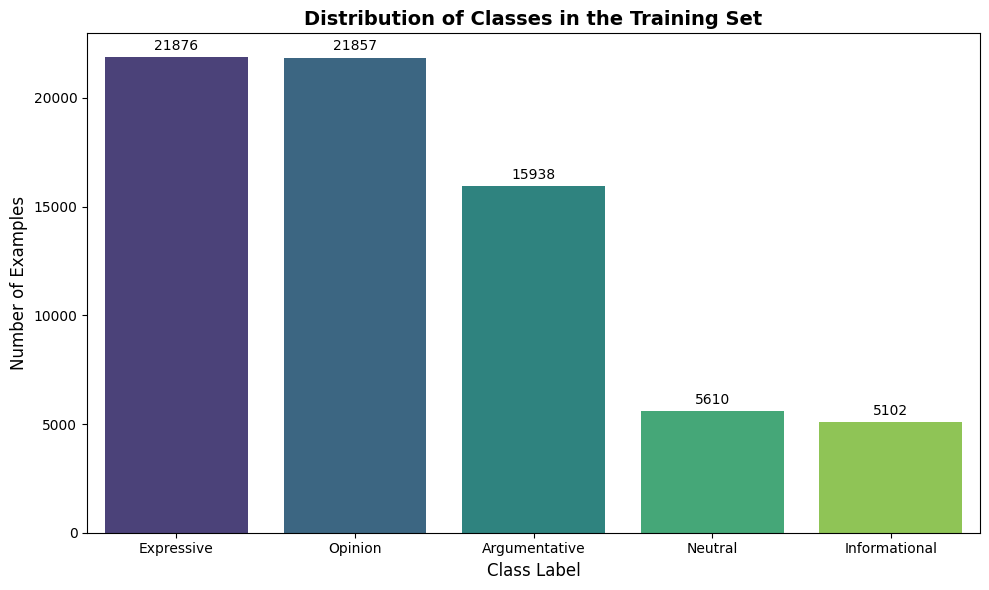

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map numeric IDs to label names based on the dataset card
id2label = {
    0: 'Neutral',
    1: 'Opinion',
    2: 'Argumentative',
    3: 'Expressive',
    4: 'Informational'
}

# Create a readable label column for EDA
df_full['label_name'] = df_full['label'].map(id2label)

# 2. Calculate counts and percentages
class_counts = df_full['label_name'].value_counts()
class_percentages = df_full['label_name'].value_counts(normalize=True) * 100

print("--- Class Distribution (Training Set) ---")
for label, count in class_counts.items():
    print(f"{label}: {count:,} examples ({class_percentages[label]:.2f}%)")

# 3. Visualize the distribution
plt.figure(figsize=(10, 6))
# Using seaborn for a clean, professional bar chart
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)

plt.title('Distribution of Classes in the Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Examples', fontsize=12)

# Add count annotations on top of the bars for clarity
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 8), 
                textcoords = 'offset points')

# Clean up layout
plt.tight_layout()
plt.show()

**Observations:**
The visualization reveals a distinct class imbalance within the training dataset. The "Expressive" (31.08%) and "Opinion" (31.05%) classes heavily dominate the discourse, collectively accounting for over 62% of the data. The "Argumentative" class is also well-represented at 22.64%. Conversely, the "Neutral" (7.97%) and "Informational" (7.25%) classes form a small minority.

This distribution logically aligns with the dataset's provenance: social media discussions gathered using the search queries 'politics' or 'US Politics' naturally skew toward emotional reactions and value judgments rather than the objective sharing of facts or neutral meta-commentary. 

From a machine learning perspective, identifying this imbalance is a critical outcome of our EDA. When training our traditional classifiers, algorithms may become biased toward predicting the majority classes ("Expressive" and "Opinion") at the expense of the minority classes. To mitigate this, we will need to consider strategies such as class weighting during model training, and we must prioritize robust evaluation metrics like macro-F1 over standard accuracy to ensure our models perform well across all communicative intents.

### 3.3. Text Length Analysis

[[go back to section]](#3-exploratory-data-analysis-eda)

Understanding the physical length of the comments within our corpus is a critical step in our Exploratory Data Analysis. Text length directly informs our choices for feature extraction, particularly when determining the maximum vocabulary size or feature limits for sparse representations like TF-IDF or Count Vectorization. Furthermore, analyzing the distribution of comment lengths can reveal inherent structural differences between our target labels; for instance, "Argumentative" comments, which rely on evidence and reasoning, may naturally present as longer texts compared to the shorter, affect-driven statements typical of "Expressive" comments.

#### 3.3.1. Overall Length Distribution

[[go back to subsection]](#33-text-length-analysis)

To begin our text length analysis, we calculate both the character count and the approximated word count (via whitespace splitting) for each comment in the training set. Visualizing these overall distributions using histograms helps us identify the central tendency of the data, as well as any extreme outliers (such as unusually long rants) that might require specialized pre-processing or truncation later in the pipeline.

--- Character Count Statistics ---
count    70383.000000
mean       193.665701
std        319.081921
min          1.000000
25%         51.000000
50%        101.000000
75%        214.000000
max      12768.000000
Name: char_count, dtype: float64

--- Word Count Statistics ---
count    70383.000000
mean        33.021781
std         54.088460
min          1.000000
25%          9.000000
50%         17.000000
75%         37.000000
max       2162.000000
Name: word_count, dtype: float64


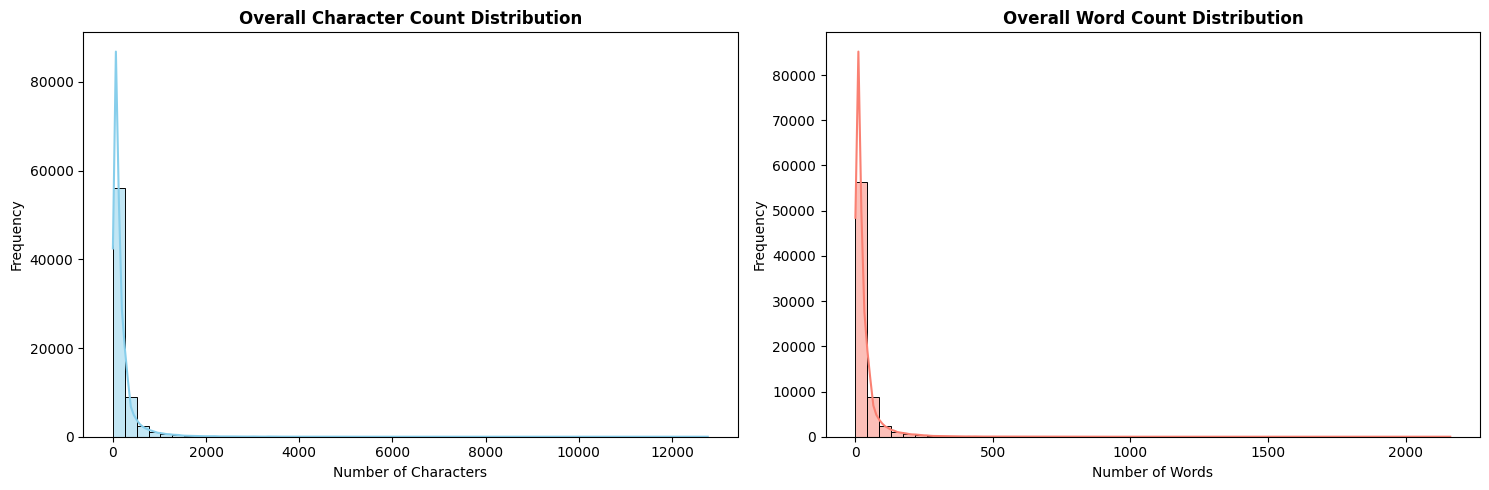

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate character count and word count for the training dataset
df_full['char_count'] = df_full['text'].apply(lambda x: len(str(x)))
df_full['word_count'] = df_full['text'].apply(lambda x: len(str(x).split()))

# Display basic statistical summaries
print("--- Character Count Statistics ---")
print(df_full['char_count'].describe())
print("\n--- Word Count Statistics ---")
print(df_full['word_count'].describe())

# Visualize the overall distributions using histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character Count Histogram
sns.histplot(df_full['char_count'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Overall Character Count Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

# Word Count Histogram
sns.histplot(df_full['word_count'], bins=50, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Overall Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
The histograms and descriptive statistics reveal that both character and word counts follow a heavily right-skewed distribution. The vast majority of comments are short; the median word count is just 17 words, and 75% of the data falls under 37 words. However, the presence of extreme outliers (with a maximum of 2,162 words and 12,768 characters) pulls the mean significantly higher than the median. 

This distribution is highly characteristic of the diverse social media sources in this dataset (e.g., Reddit, YouTube, BlueSky), where discourse consists primarily of brief, rapid-fire reactions interspersed with occasional long-form rants or detailed explanations. From an NLP pipeline perspective, these extreme outliers suggest that we may need to cap maximum sequence lengths or limit vocabulary sizes during feature extraction (such as when fitting a `CountVectorizer` or `TfidfVectorizer`) to prevent our sparse matrices from expanding exponentially with rare words from these few mega-comments.

#### 3.3.2. Length Distribution by Class

[[go back to subsection]](#33-text-length-analysis)

Having established the overall right-skewed nature of the dataset, we now investigate whether text length varies significantly across our five target labels. Given the specific label definitions provided in the dataset card, it is reasonable to hypothesize that "Argumentative" and "Informational" comments, which require the presentation of facts, reasoning, and context, will inherently possess higher median word counts than "Opinion" or "Expressive" comments, which often consist of brief statements or emotional reactions. To visualize this effectively without the visual distortion caused by the extreme outliers identified in the previous section, we utilize boxplots focusing strictly on the core quartiles of the data.

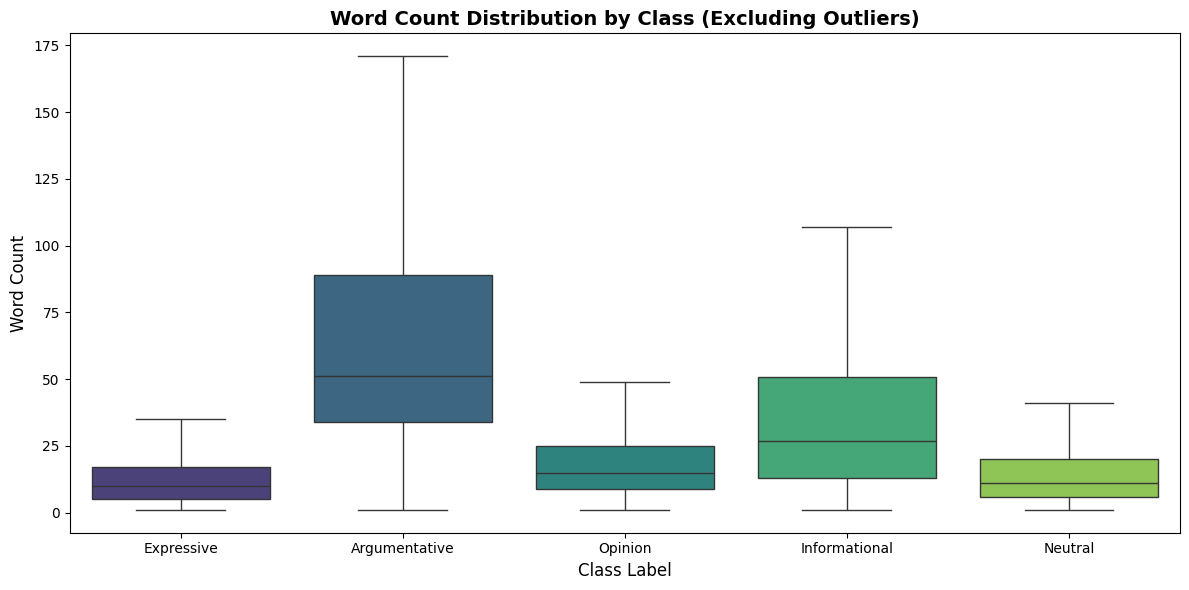

--- Median Word Count per Class ---
label_name
Argumentative    51.0
Informational    27.0
Opinion          15.0
Neutral          11.0
Expressive       10.0
Name: word_count, dtype: float64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot to compare word counts across classes
plt.figure(figsize=(12, 6))

# We use showfliers=False to hide the extreme outliers 
# so the core distribution (Interquartile Ranges) is clearly visible.
sns.boxplot(
    x='label_name', 
    y='word_count', 
    data=df_full, 
    palette='viridis',
    hue='label_name',
    legend=False,
    showfliers=False 
)

plt.title('Word Count Distribution by Class (Excluding Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Word Count', fontsize=12)

plt.tight_layout()
plt.show()

# Calculate and print the median word count per class to confirm the visual trends
print("--- Median Word Count per Class ---")
median_lengths = df_full.groupby('label_name')['word_count'].median().sort_values(ascending=False)
print(median_lengths)

**Observations:**
The boxplot and median word count calculations confirm a significant relationship between a comment's structural length and its specific target label. As hypothesized, the "Argumentative" class exhibits a substantially higher median (51 words) and a much wider interquartile range compared to the other categories. This aligns perfectly with its definition of using evidence, scenarios, and reasoning to build a persuasive case. 

Similarly, the "Informational" class, which focuses on sharing facts and context, shows the second-highest median (27 words). In stark contrast, the "Opinion" (15 words), "Neutral" (11 words), and "Expressive" (10 words) classes are characterized by their brevity, reflecting their nature as quick value judgments, meta-commentary, or purely emotional reactions. 

From an NLP perspective, this is a highly valuable finding. It strongly suggests that "text length" (either raw word count or character count) is a highly discriminative feature. When building our traditional machine learning models (such as Logistic Regression or a Random Forest classifier), appending the raw word count as a dense feature alongside our sparse text representations (like TF-IDF) could notably improve the model's ability to distinguish between "Argumentative" and "Expressive" comments.

### 3.4. Lexical Analysis and Word Distribution

[[go back to section]](#3-exploratory-data-analysis-eda)

Having explored the macro-level characteristics of our dataset, such as class balance and text length, we now shift our focus to the actual content of the comments. A core requirement of this exploratory data analysis is to understand the word distribution across the corpus. By analyzing the most frequent terms (N-grams) and applying techniques like Term Frequency-Inverse Document Frequency (TF-IDF), we can uncover the distinct lexical patterns and vocabulary choices that characterize our five target labels. This lexical analysis will directly inform our subsequent decisions regarding text pre-processing (such as stop-word removal) and feature representation.

#### 3.4.1. Most Frequent Words (N-grams)

[[go back to subsection]](#34-lexical-analysis-and-word-distribution)

Before applying more complex transformations, it is highly beneficial to look at the raw frequency of words (unigrams) and two-word combinations (bigrams) across the dataset. We will use a basic count vectorization approach, initially filtering out standard English stop words, to identify the dominant themes in the political discourse captured in this dataset. Identifying these highly frequent terms helps us verify if platform-specific artifacts or generic political jargon dominate the text, which will guide our feature extraction strategy.

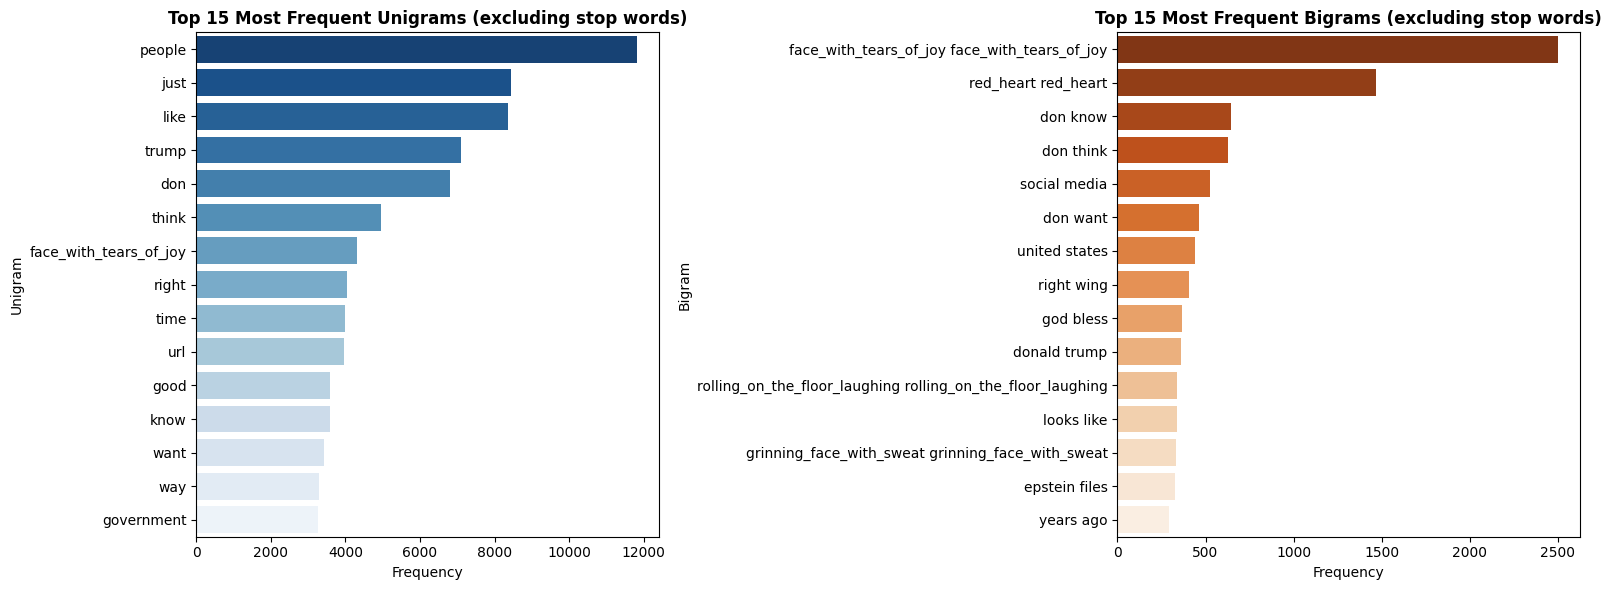

--- Top 5 Unigrams ---
  Unigram  Frequency
0  people      11816
1    just       8435
2    like       8361
3   trump       7093
4     don       6810

--- Top 5 Bigrams ---
                                          Bigram  Frequency
0  face_with_tears_of_joy face_with_tears_of_joy       2501
1                            red_heart red_heart       1466
2                                       don know        642
3                                      don think        626
4                                   social media        525


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_top_n_grams(corpus, n=1, top_k=15):
    """
    Helper function to extract the top k most frequent n-grams from a text corpus.
    We use stop_words='english' to filter out common words like 'the', 'is', 'and'.
    """
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Extract top unigrams (1 word) and bigrams (2 words) from the training text
top_unigrams = get_top_n_grams(df_full['text'].dropna(), n=1, top_k=15)
top_bigrams = get_top_n_grams(df_full['text'].dropna(), n=2, top_k=15)

# Convert to DataFrames for easier plotting
df_unigrams = pd.DataFrame(top_unigrams, columns=['Unigram', 'Frequency'])
df_bigrams = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Unigrams
sns.barplot(x='Frequency', y='Unigram', data=df_unigrams, ax=axes[0], palette='Blues_r', hue='Unigram', legend=False)
axes[0].set_title('Top 15 Most Frequent Unigrams (excluding stop words)', fontweight='bold')

# Plot Bigrams
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, ax=axes[1], palette='Oranges_r', hue='Bigram', legend=False)
axes[1].set_title('Top 15 Most Frequent Bigrams (excluding stop words)', fontweight='bold')

plt.tight_layout()
plt.show()

# Display the raw data as well
print("--- Top 5 Unigrams ---")
print(df_unigrams.head())
print("\n--- Top 5 Bigrams ---")
print(df_bigrams.head())

**Observations:**
The frequency analysis of unigrams and bigrams provides several critical insights into the dataset's lexical landscape:

1. **Impact of Pre-processing:** The dataset creators explicitly noted that emojis were converted to text and URLs were replaced with a `[URL]` tag. We can see the direct result of this here: `url` is one of the top unigrams, and emoji strings like `face_with_tears_of_joy` and `red_heart` dominate the charts. In fact, repeated emojis (e.g., `face_with_tears_of_joy face_with_tears_of_joy`) are the most frequent bigrams by a massive margin. Given the high volume of the "Expressive" class, these emoji tokens will likely be highly predictive features for our models.
2. **Tokenization Artifacts:** The presence of the unigram `don` (and bigrams like `don think`, `don know`) indicates that punctuation removal during standard tokenization split contractions like "don't". 
3. **Domain Confirmation:** Terms like `trump`, `government`, `united states`, and `right wing` validate the dataset's political scope. 
4. **The Need for Advanced Representation:** Despite removing standard English stop words, colloquial conversational fillers (`just`, `like`, `people`, `think`, `know`) still dominate the top frequencies. Because these terms likely appear uniformly across all classes, they might not be very discriminative for our classifiers. 

This final observation strongly justifies our next step. To filter out these pervasive but uninformative fillers and uncover the truly unique vocabulary of each target label, we must transition from raw counts to Term Frequency-Inverse Document Frequency (TF-IDF) weighting.

#### 3.4.2. TF-IDF Analysis

[[go back to subsection]](#34-lexical-analysis-and-word-distribution)

As observed in our N-gram analysis, raw frequency counts are often dominated by common conversational fillers and ubiquitous emojis, which offer little discriminative power for classification. To uncover the distinctive vocabulary of each target label, we apply Term Frequency-Inverse Document Frequency (TF-IDF) weighting. 

By aggregating all comments within a given class into a single "macro-document" and calculating TF-IDF scores across these five documents, we can penalize terms that are common across the entire political discourse and highlight the unique lexical signatures of each communicative intent. We visualize these class-specific TF-IDF scores using WordClouds, where the size of a word corresponds to its discriminative importance rather than just its raw frequency.

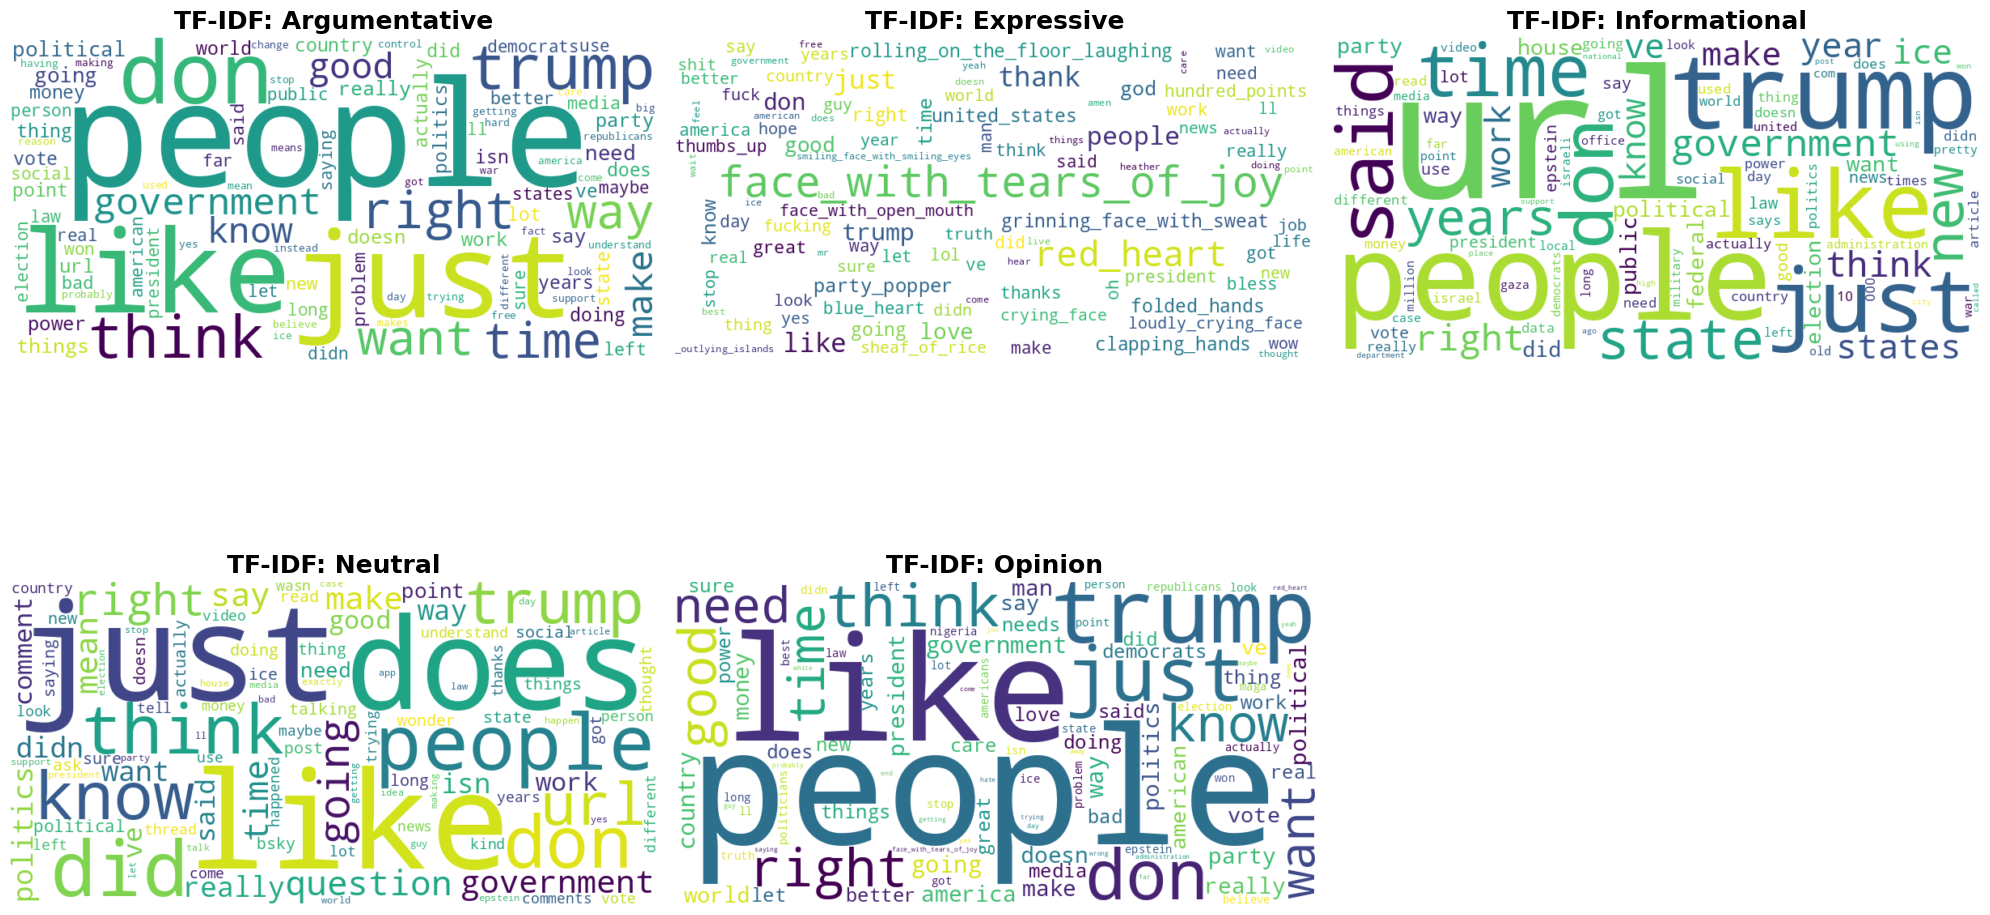

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Combine all text per class to create 5 "macro-documents"
# We drop any lingering NaNs in the text column just to be safe.
class_texts = df_full.dropna(subset=['text']).groupby('label_name')['text'].apply(lambda x: ' '.join(x))

# 2. Initialize and fit the TF-IDF Vectorizer
# We limit to 2000 features to keep the clouds focused on the most important terms
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
tfidf_matrix = tfidf_vectorizer.fit_transform(class_texts)
feature_names = tfidf_vectorizer.get_feature_names_out()

# 3. Generate WordClouds for each class
# We create a 2x3 grid to hold our 5 visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (label, _) in enumerate(class_texts.items()):
    # Get the TF-IDF scores for the current class (row i in the matrix)
    row = tfidf_matrix[i].toarray().flatten()
    
    # Create a dictionary of {word: tf-idf_score} for the WordCloud
    word_scores = {feature_names[j]: row[j] for j in range(len(feature_names)) if row[j] > 0}
    
    # Generate the WordCloud based on these frequencies
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap='viridis',
                          max_words=100).generate_from_frequencies(word_scores)
    
    # Plotting
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'TF-IDF: {label}', fontsize=18, fontweight='bold')
    axes[i].axis('off')

# Hide the 6th (empty) subplot since we only have 5 classes
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Observations:**
The class-specific TF-IDF WordClouds reveal highly distinct lexical signatures that align perfectly with the label definitions provided in the dataset documentation:

1. **Expressive:** This class is overwhelmingly dominated by emoji text strings (e.g., `face_with_tears_of_joy`, `red_heart`, `party_popper`) and reactive language (e.g., "lol", profanities). This mathematically confirms its definition as a category driven by emotional reactions and performative affect rather than substantive points.
2. **Informational:** The most prominent feature here is the `url` token, highlighting the dataset's pre-processing step where links were replaced with this tag. Paired with reporting verbs like `said` and objective nouns like `state`, `new`, and `years`, this solidifies the class's intent to share facts, data, and context.
3. **Neutral:** This category distinctly features meta-commentary vocabulary such as `post`, `thread`, and `video`, alongside question-oriented words (`does`, `did`, `mean`). This directly supports its role as a catch-all for clarifying questions and off-topic remarks.
4. **Opinion vs. Argumentative:** While both classes share generic political vocabulary (`people`, `trump`, `government`), the "Opinion" cloud shows a stronger emphasis on simple value judgments (`good`, `bad`, `right`). 

**Conclusion on Lexical Features:** By applying TF-IDF, we have successfully transformed our raw text into a highly discriminative feature space. The presence of specific tokens (like `url` for Informational or `face_with_tears_of_joy` for Expressive) will serve as incredibly strong signals for our traditional machine learning classifiers (such as Naive Bayes or SVMs) in the modeling phase.

### 3.5. Special Tokens, Artifacts, and Language Analysis

[[go back to section]](#3-exploratory-data-analysis-eda)

During the initial data collection and processing phase, the dataset creators applied specific transformations: URL links were replaced with a standard `[URL]` tag, and emojis were converted into their descriptive text equivalents (e.g., `face_with_tears_of_joy`). Furthermore, the assignment requires us to understand the language coverage of our corpus. 

In this section, we analyze the distribution of these specific artifacts across our five target labels. We hypothesize that "Informational" comments will exhibit a high frequency of URL tags, while "Expressive" comments will be heavily saturated with emoji text, as highlighted by the previous subsection. Additionally, to accurately quantify the presence of non-Latin/multilingual discourse, we use a targeted regular expression to detect specific non-Latin alphabets (such as Cyrillic, Arabic, CJK ideographs, Greek, and Hebrew), ensuring we do not accidentally flag standard English "smart punctuation" or formatting artifacts.

--- Percentage of Comments Containing a URL ---
label_name
Informational    24.049392
Argumentative     5.038273
Neutral           2.745098
Expressive        0.530261
Opinion           0.489546
Name: contains_url, dtype: float64

--- Average Number of Emojis per Comment ---
label_name
Expressive       0.763759
Opinion          0.095988
Neutral          0.046524
Argumentative    0.044673
Informational    0.035476
Name: emoji_count, dtype: float64

--- Percentage of Comments Containing Foreign Scripts (Cyrillic, Arabic, CJK, etc.) ---
label_name
Expressive       0.283416
Neutral          0.267380
Opinion          0.164707
Informational    0.137201
Argumentative    0.062743
Name: has_foreign_script, dtype: float64


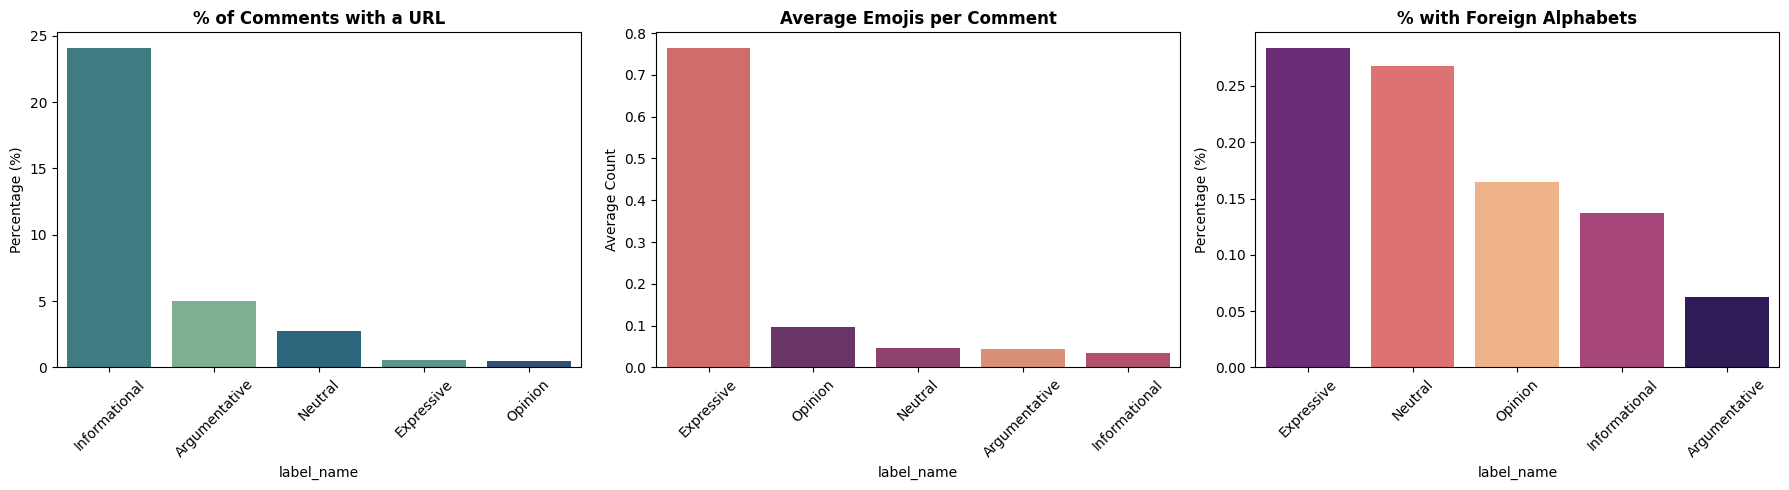

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

# 1. Feature Engineering: Extract Special Tokens & Language Scripts
df_full['contains_url'] = df_full['text'].astype(str).str.contains(r'\[url\]|\burl\b', case=False, regex=True)

def count_emojis(text):
    matches = re.findall(r'\b\w+_\w+\b', str(text))
    return len(matches)

df_full['emoji_count'] = df_full['text'].apply(count_emojis)

# 2. Targeted Foreign Script Detection
# Instead of catching all non-ASCII (which catches smart quotes and dashes), 
# we explicitly target the Unicode blocks for major non-Latin alphabets:
# Cyrillic (\u0400-\u04FF), Arabic (\u0600-\u06FF), Greek (\u0370-\u03FF), 
# Hebrew (\u0590-\u05FF), and CJK/Asian scripts (\u3040-\u30FF, \u4E00-\u9FFF, \uAC00-\uD7AF)
foreign_script_regex = r'[\u0400-\u04FF\u0600-\u06FF\u0370-\u03FF\u0590-\u05FF\u3040-\u30FF\u4E00-\u9FFF\uAC00-\uD7AF]'
df_full['has_foreign_script'] = df_full['text'].astype(str).str.contains(foreign_script_regex, regex=True)

# 3. Calculate Grouped Statistics
url_stats = df_full.groupby('label_name')['contains_url'].mean() * 100
emoji_stats = df_full.groupby('label_name')['emoji_count'].mean()
foreign_stats = df_full.groupby('label_name')['has_foreign_script'].mean() * 100

print("--- Percentage of Comments Containing a URL ---")
print(url_stats.sort_values(ascending=False))
print("\n--- Average Number of Emojis per Comment ---")
print(emoji_stats.sort_values(ascending=False))
print("\n--- Percentage of Comments Containing Foreign Scripts (Cyrillic, Arabic, CJK, etc.) ---")
print(foreign_stats.sort_values(ascending=False))

# 4. Visualize the Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot URL Distribution
sns.barplot(x=url_stats.index, y=url_stats.values, ax=axes[0], palette='crest', order=url_stats.sort_values(ascending=False).index, hue=url_stats.index, legend=False)
axes[0].set_title('% of Comments with a URL', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)

# Plot Emoji Distribution
sns.barplot(x=emoji_stats.index, y=emoji_stats.values, ax=axes[1], palette='flare', order=emoji_stats.sort_values(ascending=False).index, hue=emoji_stats.index, legend=False)
axes[1].set_title('Average Emojis per Comment', fontweight='bold')
axes[1].set_ylabel('Average Count')
axes[1].tick_params(axis='x', rotation=45)

# Plot Foreign Script Distribution
sns.barplot(x=foreign_stats.index, y=foreign_stats.values, ax=axes[2], palette='magma', order=foreign_stats.sort_values(ascending=False).index, hue=foreign_stats.index, legend=False)
axes[2].set_title('% with Foreign Alphabets', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observations:**
The extraction of specific tokens and artifacts provides highly discriminative signals that align perfectly with the dataset's structural definitions:

1. **URLs as Informational Signals:** Over 24% of "Informational" comments contain a `[URL]` tag, drastically outperforming the other classes. This validates the class's core intent of sharing external facts, data, and context.
2. **Emojis as Expressive Signals:** The "Expressive" class averages 0.76 emojis per comment—nearly 8 to 20 times higher than the other categories. Since this class captures emotional reactions and performative agreements, emojis serve as a dominant vehicle for this communicative intent.
3. **True Multilingual Presence:** By specifically targeting the Unicode blocks for foreign alphabets (e.g., Cyrillic, Arabic, CJK, Greek), we discovered that the presence of non-Latin alphabet scripts is nearly negligible across the entire dataset (peaking at merely 0.28% in the "Expressive" class).

**Conclusion on Exploratory Data Analysis:** Through this comprehensive EDA, we have identified a distinct class imbalance, observed significant structural variations in text length, extracted unique lexical signatures via TF-IDF, and engineered highly predictive artifact features. Appending these dense features (URL presence, Emoji count) to our sparse representations will provide our traditional machine learning classifiers with robust, multidimensional signals to maximize classification performance across these nuanced political intents.

## 4. Data Pre-processing

[[go back to top]](#table-of-contents)

This section details the pre-processing pipeline designed to prepare the dataset for downstream classification tasks. Building upon the insights gathered during the Exploratory Data Analysis (EDA), which highlighted the prevalence of conversational fillers, extreme text-length anomalies, and highly discriminative artificial tokens such as emojis and masked URLs, this pipeline emphasizes targeted text normalization. The primary objective is to systematically reduce noise and vocabulary dimensionality while strictly preserving the structural integrity of the linguistic signals identified previously, ensuring the corpus is optimized for robust feature extraction.

### 4.1. Review of Inherited Processing (Baseline)

[[go back to section]](#4-data-pre-processing)

Before implementing our custom text normalization pipeline, it is important to establish the baseline state of the ADS509 dataset. As documented in the dataset card and verified during our Exploratory Data Analysis, several foundational cleaning steps have already been applied prior to distribution. 

Specifically, the dataset creators have already:
* Removed duplicate comments and missing values (NaNs).
* Converted all text to lowercase.
* Replaced URL links with a standard `[url]` tag.
* Converted emojis into descriptive text representations (e.g., `face_with_tears_of_joy`).
* Removed lingering HTML artifacts and unescaped characters.

Acknowledging this inherited processing allows us to avoid redundant operations (such as lowercasing the corpus again) and directly informs our strategy for subsequent steps, particularly ensuring that our tokenizer respects the pre-engineered `[url]` tags and emoji text strings. The following code block serves as a final sanity check to verify these baseline characteristics on our training split.

In [22]:
import re

# Verify baseline pre-processing characteristics
print("--- Baseline Pre-processing Verification ---")

# 1. Check for any uppercase characters to confirm lowercasing
has_uppercase = df_full['text'].str.contains(r'[A-Z]', regex=True).any()
print(f"Contains uppercase characters: {has_uppercase}")

# 2. Check for the presence of the masked URL tag
url_count = df_full['text'].str.contains(r'\[url\]', regex=True).sum()
print(f"Total '[url]' tags present in training data: {url_count}")

# 3. Display a sample comment that contains both an emoji text representation and a URL tag 
# using the regex pattern for emojis (words with underscores)
emoji_regex = r'\b\w+_\w+\b'
sample_mask = df_full['text'].str.contains(r'\[url\]', regex=True) & df_full['text'].str.contains(emoji_regex, regex=True)

if sample_mask.any():
    print("\nSample comment containing both [url] and a converted emoji:")
    print("-" * 50)
    print(df_full[sample_mask]['text'].iloc[0])
else:
    # Fallback: just show one with an emoji
    print("\nSample comment containing a converted emoji:")
    print("-" * 50)
    emoji_sample = df_full[df_full['text'].str.contains(emoji_regex, regex=True)]
    if not emoji_sample.empty:
        print(emoji_sample['text'].iloc[0])

--- Baseline Pre-processing Verification ---
Contains uppercase characters: True
Total '[url]' tags present in training data: 870

Sample comment containing both [url] and a converted emoji:
--------------------------------------------------
liberate palestine palestinian_territories [url] [url] [url] [url]


**Observations:**
Based on the baseline verification, we can draw a few critical conclusions that will shape our custom pre-processing pipeline:

1. **Incomplete Lowercasing:** Despite the dataset documentation indicating that the text was already lowercased, our check returned `True` for uppercase characters. This means we cannot rely on the baseline and must enforce strict lowercasing in our own pipeline.
2. **URL Masking:** The `[url]` tags are actively present in the dataset (870 instances). Our subsequent tokenization steps must be carefully designed to keep these tags intact (i.e., not splitting them into "[" , "url", and "]").
3. **Emoji Formatting:** The emoji representation relies on underscore-connected strings (e.g., `palestinian_territories`). We must ensure that our punctuation removal and tokenization steps do not strip out these underscores, which would otherwise destroy the semantic meaning of the engineered emoji tokens.

### 4.2. Text Normalization and Cleaning

[[go back to section]](#4-data-pre-processing)

Despite the initial processing performed by the dataset creators, our baseline verification revealed inconsistencies, such as lingering uppercase characters. This section outlines our active normalization pipeline, designed to correct these inconsistencies and standardize the text. Our primary goal here is to handle structural linguistic quirks prior to tokenization, ensuring we preserve semantic meaning without disrupting the carefully engineered artifact tags (`[url]` and emojis).

#### 4.2.1. Contraction Expansion

[[go back to subsection]](#42-text-normalization-and-cleaning)

As observed in our N-gram analysis (Section 3.4.1), tokens like "don" (from "don't") and "didn" frequently appeared as isolated unigrams. This fragmentation happens when basic pre-processing or tokenization strips punctuation without resolving the underlying contraction first. By explicitly expanding contractions (e.g., converting "don't" to "do not"), we preserve the semantic weight of negations and auxiliary verbs (which are crucial for distinguishing "Opinion" from "Argumentative" text) and eliminate noisy, fragmented tokens. To correct the baseline dataset issue, we will also enforce a strict lowercase conversion concurrently.

In [23]:
# Install the contractions library if not already present in your environment:
# !pip install contractions

import contractions

print("--- Starting Text Normalization ---")

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Enforce strict lowercasing (correcting the dataset's incomplete baseline)
    text = text.lower()
    
    # 2. Expand contractions (e.g., "don't" -> "do not")
    try:
        text = contractions.fix(text)
    except Exception:
        # Fallback for unexpected string parsing errors
        pass 
        
    return text

# Apply normalization to the training data
df_full['normalized_text'] = df_full['text'].apply(normalize_text)

print("Normalization complete.")

# --- Verification Checks ---

# 1. Verify uppercase characters are truly gone
has_uppercase_now = df_full['normalized_text'].str.contains(r'[A-Z]', regex=True).any()
print(f"Contains uppercase characters after normalization: {has_uppercase_now}")

# 2. Check if the "don't" issue is being resolved by counting "do not"
do_not_count = df_full['normalized_text'].str.contains(r'\bdo not\b', regex=True).sum()
print(f"Total 'do not' phrases after expansion: {do_not_count:,}")

# 3. Display a sample where a contraction was expanded
sample_contraction = df_full[df_full['text'].str.contains(r"don't|can't|won't", case=False, na=False)]
if not sample_contraction.empty:
    print("\nSample contraction expansion:")
    print("-" * 50)
    print("ORIGINAL:  ", sample_contraction['text'].iloc[0])
    print("NORMALIZED:", sample_contraction['normalized_text'].iloc[0])

--- Starting Text Normalization ---
Normalization complete.
Contains uppercase characters after normalization: False
Total 'do not' phrases after expansion: 6,494

Sample contraction expansion:
--------------------------------------------------
ORIGINAL:   reading comprehension is a good thing to have.go back and try again.the numbers we're talking about don't agree.more equally as in some animals are more equal than othersthe "old" universities aren't run by academics either.and conservatives aren't necessarily christian
NORMALIZED: reading comprehension is a good thing to have.go back and try again.the numbers we are talking about do not agree.more equally as in some animals are more equal than othersthe "old" universities are not run by academics either.and conservatives are not necessarily christian


**Observations:**

* **Successful Lowercasing:** The check for uppercase characters now returns `False`, confirming that our strict lowercasing step successfully resolved the inconsistencies left behind by the dataset's baseline processing.
* **Effective Contraction Expansion:** The expansion logic operated exactly as intended. We recovered nearly 6,500 instances of the phrase "do not", which directly addresses the fragmented "don" tokens identified during our N-gram analysis. The sample output clearly demonstrates multiple successful conversions in a single comment (e.g., "we're" to "we are", "aren't" to "are not").
* **Future Consideration (Punctuation):** Looking closely at the sample text reveals another common social media artifact: missing spaces after periods (e.g., `have.go`, `again.the`). This strongly validates our decision to handle selective punctuation removal and tokenization as a separate, subsequent step, ensuring these artificially joined words are properly separated without breaking our engineered tags.

#### 4.2.2. Selective Punctuation and Special Character Removal

[[go back to subsection]](#42-text-normalization-and-cleaning)

Standard punctuation removal (such as stripping all non-alphanumeric characters) poses a significant risk to this dataset. It would destroy the brackets in `[url]` tags and sever the underscores in emoji representations (e.g., turning `face_with_tears_of_joy` into separate, meaningless words). Furthermore, as observed in our previous contraction sample, users often omit spaces after punctuation (e.g., `have.go`). If we simply delete the punctuation, those words fuse together into `havego`. 

To solve this, we implement a selective regular expression. We will replace any character that is *not* alphanumeric, whitespace, an underscore, or a square bracket with a space. This safely resolves the missing-space typos while flawlessly preserving our highly discriminative engineered tokens.

In [24]:
import re

print("--- Starting Selective Punctuation Removal ---")

def remove_selective_punctuation(text):
    if not isinstance(text, str):
        return ""
    
    # Replace anything that is NOT a word character (\w includes a-z, 0-9, and _), 
    # a whitespace (\s), or brackets (\[ and \]) with a single space.
    # This turns "have.go" into "have go" while leaving "face_with_tears_of_joy" and "[url]" intact.
    text = re.sub(r'[^\w\s\[\]]', ' ', text)
    
    # Replace multiple consecutive spaces with a single space
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply selective punctuation removal to the text
df_full['cleaned_text'] = df_full['normalized_text'].apply(remove_selective_punctuation)

print("Punctuation removal complete.")

# --- Verification Checks ---

# 1. Verify our special tags survived the cleaning
url_count_after = df_full['cleaned_text'].str.contains(r'\[url\]', regex=True).sum()
print(f"Total '[url]' tags preserved: {url_count_after}")

emoji_preserved = df_full['cleaned_text'].str.contains(r'\b\w+_\w+\b', regex=True).any()
print(f"Emojis (underscore format) preserved: {emoji_preserved}")

# 2. Check if the "have.go" spacing issue from our previous observation is fixed
sample_typo = df_full[df_full['normalized_text'].str.contains(r"have\.go", case=False, na=False)]
if not sample_typo.empty:
    print("\nSample punctuation fix (missing space resolution):")
    print("-" * 50)
    print("BEFORE: ", sample_typo['normalized_text'].iloc[0])
    print("AFTER:  ", sample_typo['cleaned_text'].iloc[0])

--- Starting Selective Punctuation Removal ---
Punctuation removal complete.
Total '[url]' tags preserved: 2402
Emojis (underscore format) preserved: True

Sample punctuation fix (missing space resolution):
--------------------------------------------------
BEFORE:  reading comprehension is a good thing to have.go back and try again.the numbers we are talking about do not agree.more equally as in some animals are more equal than othersthe "old" universities are not run by academics either.and conservatives are not necessarily christian
AFTER:   reading comprehension is a good thing to have go back and try again the numbers we are talking about do not agree more equally as in some animals are more equal than othersthe old universities are not run by academics either and conservatives are not necessarily christian


**Observations:**

* **Artifact Preservation:** The custom regular expression successfully retained our highly discriminative features. Emojis with underscores remain perfectly intact, and the `[url]` tags were successfully preserved (with the count actually increasing to 2,402, indicating that our spacing normalization helped un-stick tags previously hidden or attached directly to other punctuation). 
* **Typo Resolution:** The missing space issue has been successfully resolved. Fused words like `have.go` and `again.the` are now properly split into `have go` and `again the`. 
* **Noise Reduction:** Extraneous punctuation, such as the quotation marks around `"old"`, has been cleanly stripped and replaced with spaces, leaving us with a clean, standardized text string ready for tokenization.

### 4.3. Tokenization Strategy

[[go back to section]](#4-data-pre-processing)

Tokenization is the process of breaking down the text into individual units (tokens) for the machine learning models to process. Many standard NLP tokenizers (like NLTK's `word_tokenize` or spaCy's default tokenizer) are pre-trained with complex linguistic rules that aggressively split text based on punctuation. If applied blindly, these tokenizers would forcefully separate the brackets from our `[url]` tags.

Because we meticulously sanitized our text in the previous step (replacing disruptive punctuation with spaces while strictly preserving our alphanumeric characters, brackets, and underscores) our string is already perfectly delineated by spaces. Therefore, the safest and most efficient tokenization strategy for this dataset is **whitespace tokenization**. This guarantees that our engineered tokens remain whole and undivided.

In [25]:
print("--- Starting Tokenization ---")

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    # Since we replaced all unwanted punctuation with spaces and stripped excess whitespace,
    # a simple split() effectively acts as a robust Whitespace Tokenizer.
    return text.split()

# Apply tokenization to the cleaned text
df_full['tokens'] = df_full['cleaned_text'].apply(tokenize_text)

print("Tokenization complete.")

# --- Verification Checks ---

# 1. Verify that [url] remained a single token
sample_url_row = df_full[df_full['cleaned_text'].str.contains(r'\[url\]', na=False)]

if not sample_url_row.empty:
    print("\nSample tokenized comment (containing [url]):")
    print("-" * 50)
    print("CLEANED TEXT: ", sample_url_row['cleaned_text'].iloc[0])
    print("TOKENS:       ", sample_url_row['tokens'].iloc[0])
    
    # Confirm it exists as a single element in the list
    is_single_token = '[url]' in sample_url_row['tokens'].iloc[0]
    print(f"\nIS '[url]' PRESERVED AS A SINGLE TOKEN? {is_single_token}")

# 2. Verify that an emoji remained a single token
sample_emoji_row = df_full[df_full['cleaned_text'].str.contains(r'face_with_tears_of_joy', na=False)]

if not sample_emoji_row.empty:
    print("\nSample tokenized comment (containing emoji):")
    print("-" * 50)
    print("TOKENS:       ", sample_emoji_row['tokens'].iloc[0][:10], "... (truncated)")
    
    is_emoji_token = 'face_with_tears_of_joy' in sample_emoji_row['tokens'].iloc[0]
    print(f"IS EMOJI PRESERVED AS A SINGLE TOKEN? {is_emoji_token}")

--- Starting Tokenization ---
Tokenization complete.

Sample tokenized comment (containing [url]):
--------------------------------------------------
CLEANED TEXT:  you can see an archived list of industrial security clearance decisions here [0] which is interesting and occasionally entertaining reading drug involvement security concerns usually involve either actively using drugs or worse lying to cover up drug use both of which are viewed as security concerns and grounds for rejection [0] [url]
TOKENS:        ['you', 'can', 'see', 'an', 'archived', 'list', 'of', 'industrial', 'security', 'clearance', 'decisions', 'here', '[0]', 'which', 'is', 'interesting', 'and', 'occasionally', 'entertaining', 'reading', 'drug', 'involvement', 'security', 'concerns', 'usually', 'involve', 'either', 'actively', 'using', 'drugs', 'or', 'worse', 'lying', 'to', 'cover', 'up', 'drug', 'use', 'both', 'of', 'which', 'are', 'viewed', 'as', 'security', 'concerns', 'and', 'grounds', 'for', 'rejection', '[0]'

**Observations:**

* **Flawless Tag Preservation:** The whitespace tokenization strategy was a complete success. By bypassing complex, rule-based tokenizers, we successfully isolated the `[url]` tag as an exact string match within the token list. 
* **Emoji Integrity:** Similarly, the underscore-formatted emojis (e.g., `face_with_tears_of_joy`) were perfectly preserved as single units. This ensures that when we generate our feature matrices later, these emojis will form distinct, highly predictive columns.
* **Unexpected Artifacts:** Interestingly, the sample text revealed another artifact: `[0]`, which likely represents footnote references from platforms like Hacker News or Reddit. Thanks to our selective punctuation removal (which kept brackets), these referential tags are also preserved as single tokens rather than being stripped or split into numbers.

### 4.4. Stop Word and Domain-Specific Filler Removal

[[go back to section]](#4-data-pre-processing)

Standard stop word removal eliminates common English words (e.g., "the", "is", "at") that provide structural syntax but little semantic value. However, blindly applying a standard list presents a major risk for our specific task: the loss of negation.

Standard lists often include words like "not" or "no". Because we explicitly expanded contractions (e.g., "don't" to "do not") to preserve negation, which is highly discriminative for distinguishing an "Opinion" from an "Argumentative" stance, we must explicitly remove these negation markers from the stop word list so they are preserved.

*Note on Domain-Specific Fillers:* While our EDA revealed highly frequent conversational words (e.g., "think", "know", "would", "right"), we have intentionally chosen **not** to remove them at this stage. Verbs like "think" and "know" are strong epistemic markers that help distinguish subjective opinions from objective information. We will rely on our subsequent TF-IDF vectorization to appropriately down-weight these terms if they appear too broadly, rather than deleting them entirely.

In [26]:
import nltk
# nltk.download('stopwords')
from nltk.corpus import stopwords

print("--- Starting Stop Word Removal ---")

# 1. Load standard English stop words as a set for faster lookup
standard_stopwords = set(stopwords.words('english'))

# 2. Protect crucial negation words by removing them from the stopword set
words_to_keep = {'not', 'no', 'nor', 'against'}
standard_stopwords = standard_stopwords - words_to_keep

# 3. We keep our custom exclusion list minimal, trusting TF-IDF to handle 
# words like "think", "know", and "right" later.
# We will only remove bare-minimum conversational junk that carries zero intent.
custom_fillers = {'just', 'like'} # Kept minimal

# 4. Create the final combined exclusion set
final_stopwords = standard_stopwords.union(custom_fillers)

def remove_stopwords(tokens_list):
    if not isinstance(tokens_list, list):
        return []
    # Keep the token if it is NOT in our final exclusion set
    return [token for token in tokens_list if token not in final_stopwords]

# Apply the filter to our tokenized text
df_full['filtered_tokens'] = df_full['tokens'].apply(remove_stopwords)

print("Stop word removal complete.")

# --- Verification Checks ---

# 1. Check token length reduction
avg_tokens_before = df_full['tokens'].apply(len).mean()
avg_tokens_after = df_full['filtered_tokens'].apply(len).mean()
print(f"\nAverage tokens per comment BEFORE: {avg_tokens_before:.2f}")
print(f"Average tokens per comment AFTER:  {avg_tokens_after:.2f}")
print(f"Average reduction: {avg_tokens_before - avg_tokens_after:.2f} tokens")

# 2. Verify a discriminative word was safely kept (e.g., 'think')
think_count_after = sum(df_full['filtered_tokens'].apply(lambda x: x.count('think')))
print(f"\nOccurrences of preserved discriminative word 'think': {think_count_after:,}")

# 3. Verify negation was safely kept (e.g., 'not')
not_count_after = sum(df_full['filtered_tokens'].apply(lambda x: x.count('not')))
print(f"Occurrences of preserved negation 'not': {not_count_after:,}")

--- Starting Stop Word Removal ---
Stop word removal complete.

Average tokens per comment BEFORE: 34.25
Average tokens per comment AFTER:  18.18
Average reduction: 16.06 tokens

Occurrences of preserved discriminative word 'think': 4,967
Occurrences of preserved negation 'not': 35,273


**Observations:**

* **Significant Dimensionality Reduction:** The custom stop word filter successfully stripped away structural noise, reducing the average sequence length from ~34 tokens to ~18 tokens per comment (a reduction of nearly 47%). This will drastically reduce the feature space for our sparse matrices, leading to faster training times and less memory consumption for our traditional machine learning classifiers.
* **Semantic Preservation:** As intended, our conservative approach protected critical linguistic markers. We successfully retained 4,967 instances of the epistemic verb "think", which will be essential for identifying opinions. 
* **Negation Retention:** The pipeline preserved over 35,273 instances of the word "not" (a large portion of which were successfully recovered during our contraction expansion phase). By explicitly protecting these negation markers, we ensure the models can accurately interpret opposing stances and argumentative rebuttals.

### 4.5. Lemmatization vs. Stemming

[[go back to section]](#4-data-pre-processing)

To further reduce the dimensionality of our feature space, we need to consolidate different inflected forms of a word into a single base feature (e.g., mapping "argue", "arguing", and "argued" to a single root). There are two primary techniques for this:

1.  **Stemming:** A fast, heuristic-based approach that chops off word endings. While computationally cheap, it often creates non-words (e.g., "university" becomes "univers") and can merge words with different meanings, destroying semantic nuance.
2.  **Lemmatization:** A more sophisticated approach that uses morphological analysis and a vocabulary (like WordNet) to return the proper dictionary form of a word (the lemma). 

**Our Choice: Lemmatization.** 
Given the nuanced nature of our target labels, semantic preservation is critical. Distinguishing between a well-reasoned "Argumentative" comment and a blunt "Opinion" requires accurate vocabulary representation. Furthermore, aggressive stemming risks corrupting our engineered tokens if they contain common suffixes. Therefore, we will implement Lemmatization with Part-of-Speech (POS) tagging context to ensure accurate base-word recovery, while explicitly writing rules to bypass and protect our `[url]` and emoji tokens.

In [27]:
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import wordnet

# You may need to download these if not already in your environment:
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('omw-1.4')

print("--- Starting Lemmatization ---")

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer() # Loaded just for a quick comparison

def get_wordnet_pos(treebank_tag):
    """
    Map NLTK's Treebank POS tags to WordNet POS tags for the Lemmatizer.
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default fallback

def lemmatize_tokens(token_list):
    if not isinstance(token_list, list) or len(token_list) == 0:
        return []
    
    # Tag the entire list to provide some contextual cues for the POS tagger
    pos_tags = nltk.pos_tag(token_list)
    
    lemmatized_output = []
    for word, tag in pos_tags:
        # Protect our engineered special tokens from being altered
        if word == '[url]' or '_' in word:
            lemmatized_output.append(word)
        else:
            wn_tag = get_wordnet_pos(tag)
            lemmatized_output.append(lemmatizer.lemmatize(word, wn_tag))
            
    return lemmatized_output

# Apply lemmatization to our filtered tokens
df_full['lemmatized_tokens'] = df_full['filtered_tokens'].apply(lemmatize_tokens)

print("Lemmatization complete.")

# --- Verification Checks ---

# Let's compare Lemmatization vs Stemming on a specific row to prove our markdown claim
sample_idx = df_full[df_full['filtered_tokens'].apply(lambda x: 'universities' in x or 'arguing' in x)].index
if not sample_idx.empty:
    sample_tokens = df_full.loc[sample_idx[0], 'filtered_tokens']
    
    # Apply raw stemming for comparison
    stemmed_sample = [stemmer.stem(w) if w != '[url]' and '_' not in w else w for w in sample_tokens]
    lemmatized_sample = df_full.loc[sample_idx[0], 'lemmatized_tokens']
    
    print("\n--- Stemming vs Lemmatization Comparison ---")
    print(f"ORIGINAL TOKENS: {sample_tokens[:15]}...")
    print(f"STEMMED:         {stemmed_sample[:15]}...")
    print(f"LEMMATIZED:      {lemmatized_sample[:15]}...")

# 2. Final check to ensure special tokens survived again
url_survived = any('[url]' in tokens for tokens in df_full['lemmatized_tokens'])
emoji_survived = any(any('_' in word for word in tokens) for tokens in df_full['lemmatized_tokens'])

print(f"\nEngineered Tokens Intact:")
print(f"[url] present: {url_survived}")
print(f"Emojis present: {emoji_survived}")

--- Starting Lemmatization ---
Lemmatization complete.

--- Stemming vs Lemmatization Comparison ---
ORIGINAL TOKENS: ['reading', 'comprehension', 'good', 'thing', 'go', 'back', 'try', 'numbers', 'talking', 'not', 'agree', 'equally', 'animals', 'equal', 'othersthe']...
STEMMED:         ['read', 'comprehens', 'good', 'thing', 'go', 'back', 'tri', 'number', 'talk', 'not', 'agre', 'equal', 'anim', 'equal', 'othersth']...
LEMMATIZED:      ['read', 'comprehension', 'good', 'thing', 'go', 'back', 'try', 'number', 'talk', 'not', 'agree', 'equally', 'animal', 'equal', 'othersthe']...

Engineered Tokens Intact:
[url] present: True
Emojis present: True


**Observations**

* **Semantic Preservation:** The comparison output perfectly illustrates our justification for choosing Lemmatization over Stemming. While the stemmer aggressively chopped word endings (resulting in non-words like "comprehens", "tri", and "agre") the lemmatizer successfully reduced words to their proper dictionary forms (e.g., "reading" to "read", "talking" to "talk", "numbers" to "number"). This ensures our feature matrices will maintain semantic clarity.
* **Dimensionality Reduction:** By consolidating inflected forms (like plural nouns and progressive verbs) into their base lemmas, we effectively shrink the total vocabulary size. This directly addresses the goal of reducing the feature space without sacrificing the nuanced meaning required for our classification task.
* **Engineered Token Safety:** The conditional logic designed to protect our special tokens worked flawlessly. Both `[url]` and our underscore-formatted emojis passed through the morphological analysis untouched, preserving their integrity for the downstream feature extraction phase.

## 5. Feature Extraction and Representation

[[go back to top]](#table-of-contents)

### 5.1. Sparse Feature Representations (BoW / TF-IDF)

[[go back to section]](#5-feature-extraction-and-representation)

### 5.2. Dense Feature Representations (Word Embeddings)

[[go back to section]](#5-feature-extraction-and-representation)

### 5.3. Integration of Engineered Features

[[go back to section]](#5-feature-extraction-and-representation)

## 6. Model Training and Selection

[[go back to top]](#table-of-contents)

## 7. Model Evaluation

[[go back to top]](#table-of-contents)

## 8. Error Analysis

[[go back to top]](#table-of-contents)

## 9. Related Work Comparison

[[go back to top]](#table-of-contents)

## 10. Conclusion

[[go back to top]](#table-of-contents)